<div style="text-align: center;">
    <h1><strong>Alma Mater Studiorum - University of Bologna</strong></h1>
    

<div style="display:flex; justify-content:center; align-items:center; padding:5px;">
        <img src="../images_reports/image.png" style="height:300px; width:auto">
    </div>

<h2><strong>Cybersecurity</strong></h2>

<h3><strong>PROYECT</strong><br>
    <strong>Attacker Behavioral Profiling in SSH honeypots.</strong></h3>

<p><strong>STUDENTS</strong></p>
    <ul style="list-style-type:none; padding: 0;">
        <li><strong>Rubén Gil Martínez<strong></li>
        <li><strong>Guillermo López Pérez<strong></li>
        <li><strong>Jorge Mejías Donoso<strong></li>
    </ul>
</div>


- ### ***Research question***

**Can machine learning models accurately classify attackers into distinct behavioral**
**profiles (automated bots, script kiddies, skilled operators) based on their command**
**sequences and interaction patterns in SSH honeypots?**


## **2) Simple Unsupervised Approaches: Clustering with Different Algorithms to Identify Attacker Types**

Before applying more advanced or iterative clustering techniques, it is useful to explore
how simpler unsupervised methods behave on the dataset. These approaches serve as an
initial baseline and help reveal whether attacker behaviors naturally separate into
distinct groups using classical clustering algorithms.

In this section, we begin by loading the full behavioral dataset, cleaning missing
values, and preparing the data for several clustering methods. The goal is to observe:

- whether clear clusters emerge without supervision,
- which behavioral dimensions dominate the separation,
- and how well simple algorithms can distinguish attacker categories such as bots,
  script kiddies, and skilled human operators.

This initial exploration provides a reference point for evaluating the strengths and
limitations of unsupervised techniques before moving to more robust or hierarchical
approaches.


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import plotly.graph_objects as go
from sklearn.manifold import TSNE  
from sklearn.preprocessing import MinMaxScaler
import warnings
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


In [2]:
# ==========================
# 1) Load Dataset
# ==========================
final_dataset = pd.read_csv("../DATASETS/attacker_behavioral_profiles_dataset_3.0.csv", index_col="session_id")
df = final_dataset.copy()
df = df.dropna(inplace=False, axis=0)  # Just in case there are NaN values
df


,num_events,num_commands,session_duration,max_inter_command_time,mean_inter_command_time,std_inter_command_time,command_error_rate,file_transfer_ratio,login_error_rate,reconnaissance_ratio,exploit_ratio,unique_commands_ratio,command_diversity
session_id,,,,,,,,,,,,,
00081b571122,78.0,23.0,31.249671,6.333993,1.160163,1.173813,0.086957,0.173913,0.0,0.025641,0.064103,0.538462,19.0
0076d693f7fd,78.0,23.0,32.132288,6.536506,1.194688,1.211933,0.086957,0.173913,0.0,0.025641,0.064103,0.538462,19.0
00aa3ae5d33a,78.0,23.0,36.995369,7.981335,1.388428,1.529704,0.086957,0.173913,0.0,0.025641,0.064103,0.538462,19.0
010ad96c3f21,16.0,7.0,68.448152,19.502649,3.257964,7.958238,0.428571,0.000000,0.0,0.000000,0.062500,0.285714,6.0
012f382592c2,78.0,23.0,6.000740,0.534131,0.201693,0.094307,0.086957,0.173913,0.0,0.025641,0.064103,0.538462,19.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
ff1982e219ea,41.0,19.0,29.589802,1.698201,1.208509,0.208796,0.000000,0.000000,0.0,0.048780,0.024390,0.558824,16.0
ff30a7409bb0,78.0,23.0,26.672534,5.367225,0.980449,0.995405,0.086957,0.173913,0.0,0.025641,0.064103,0.538462,19.0
ff46f283de84,18.0,8.0,2.415998,0.274037,0.073823,0.119185,0.375000,0.000000,0.0,0.000000,0.055556,0.300000,8.0


## **1º Approach: Heuristic Clustering by Nearest Seed:**

After performing an exhaustive analysis of the samples using NumPy and pandas, we adopted a heuristic clustering strategy based on the nearest representative seed.

- **How it works:** We manually selected three specific sessions that best represent the *Bot*, *Script Kiddie*, and *Skilled Operator* profiles. Each remaining session was then classified according to its Euclidean distance to these seeds, effectively assigning it to the closest behavioral prototype.

### **Why These Seeds?**
The three seed sessions were chosen after reviewing hundreds of samples and identifying
clear representatives of each attacker profile:

- **Bot seed:** highly repetitive, low-diversity, automated behavior.
- **Script kiddie seed:** inconsistent timing, high error rate, limited command usage.
- **Skilled operator seed:** diverse commands, irregular pacing, low number of mistakes.

Each seed acts as a behavioral prototype. By measuring the **Euclidean distance** from
every session to these three seeds (after feature scaling), we can classify each sample
according to the most similar behavioral pattern.

### **How the Code Works**
1. **Extract representative samples** for the three attacker categories.
2. **Scale all features** using `StandardScaler` to ensure fair distance comparison.
3. For each session, **compute distances** to the three seeds.
4. **Assign the session to the nearest seed**, effectively clustering the dataset into:
   - `bot`
   - `sk` (script kiddie)
   - `pro` (skilled operator)

### **Purpose of this Heuristic Approach**
This method serves as a **baseline unsupervised classifier**, allowing us to examine:

- whether attacker behaviors form well-defined clusters in feature space,
- how distinct the three profiles are when compared via simple distance metrics,
- and the limitations of heuristic clustering when applied to heterogeneous attacker activity.

The results printed below show the class distribution obtained using this nearest-seed strategy.


In [3]:
bot_sample = df.loc['ffbf6704050d'] 
sk_sample = df.loc['01efe494fcc0']
pro_sample = df.loc['da9c22b09ad5']

print("Bot Sample:\n", bot_sample)
print("\nScript kiddy Sample:\n", sk_sample)
print("\nSkilled Operator Sample:\n", pro_sample)

Bot Sample:
 num_events                 41.000000
num_commands               19.000000
session_duration            5.556982
max_inter_command_time      0.218076
mean_inter_command_time     0.185133
std_inter_command_time      0.044433
command_error_rate          0.000000
file_transfer_ratio         0.000000
login_error_rate            0.000000
reconnaissance_ratio        0.048780
exploit_ratio               0.024390
unique_commands_ratio       0.558824
command_diversity          16.000000
Name: ffbf6704050d, dtype: float64

Script kiddy Sample:
 num_events                 16.000000
num_commands                7.000000
session_duration           68.608636
max_inter_command_time     19.424206
mean_inter_command_time     3.242624
std_inter_command_time      7.927324
command_error_rate          0.428571
file_transfer_ratio         0.000000
login_error_rate            0.000000
reconnaissance_ratio        0.000000
exploit_ratio               0.062500
unique_commands_ratio       0.285714
comm

In [4]:
# ==============================
# 1) Dataset and samples
# ==============================
samples = {
    'bot': bot_sample,
    'sk': sk_sample,
    'pro': pro_sample
}

# ==============================
# 2) Scaling
# ==============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
samples_scaled = {k: scaler.transform(v.values.reshape(1, -1))[0] for k, v in samples.items()}

# ==============================
# 3) Calculate distances and assign labels
# ==============================
labels = []
for x in X_scaled:
    dists = {label: np.linalg.norm(x - s) for label, s in samples_scaled.items()}
    nearest_label = min(dists, key=dists.get)
    labels.append(nearest_label)

df['cluster'] = labels

# ==============================
# 4) Results
# ==============================
print(df['cluster'].value_counts())

warnings.filterwarnings("ignore")


C:\Users\Jorge\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Jorge\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Jorge\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


cluster
bot    17491
pro     1624
sk      1271
Name: count, dtype: int64


- ### ***Different examples of the behaviour of the classified attackers***

In order to validate the heuristic clustering results, we inspect a few representative
samples from each predicted class: *script kiddies*, *skilled operators*, and *bots*.
By reviewing their behavioral features, we can check whether the nearest-seed assignment
aligns with the expected characteristics of each attacker type.

Below we display the first five sessions classified into each group. These examples help
assess whether the clusters reflect meaningful behavioral differences and whether the
seed-based approach captures the intended profiles.


In [5]:
df[df['cluster'] == 'sk'].head(5)

,num_events,num_commands,session_duration,max_inter_command_time,mean_inter_command_time,std_inter_command_time,command_error_rate,file_transfer_ratio,login_error_rate,reconnaissance_ratio,exploit_ratio,unique_commands_ratio,command_diversity,cluster
session_id,,,,,,,,,,,,,,
010ad96c3f21,16.0,7.0,68.448152,19.502649,3.257964,7.958238,0.428571,0.0,0.0,0.0,0.0625,0.285714,6.0,sk
01efe494fcc0,16.0,7.0,68.608636,19.424206,3.242624,7.927324,0.428571,0.0,0.0,0.0,0.0625,0.285714,6.0,sk
02c2ce40e41c,16.0,7.0,68.342209,19.261767,3.215242,7.861160,0.428571,0.0,0.0,0.0,0.0625,0.285714,6.0,sk
035b50f2544d,16.0,7.0,68.438979,19.373217,3.233841,7.906647,0.428571,0.0,0.0,0.0,0.0625,0.285714,6.0,sk
035dd32418e4,16.0,7.0,68.254606,19.170161,3.198320,7.824572,0.428571,0.0,0.0,0.0,0.0625,0.285714,6.0,sk


In [6]:
df[df['cluster'] == 'pro'].head(5)

,num_events,num_commands,session_duration,max_inter_command_time,mean_inter_command_time,std_inter_command_time,command_error_rate,file_transfer_ratio,login_error_rate,reconnaissance_ratio,exploit_ratio,unique_commands_ratio,command_diversity,cluster
session_id,,,,,,,,,,,,,,
0148a3eded81,79.0,23.0,47.535764,9.728765,1.794312,1.813615,0.086957,0.217391,0.0,0.025316,0.075949,0.538462,19.0,pro
0263a6b216dd,77.0,23.0,42.055636,9.345013,1.579619,1.763732,0.086957,0.130435,0.0,0.025974,0.051948,0.538462,19.0,pro
03d38ceec47c,78.0,23.0,36.687426,9.491522,1.401401,1.836347,0.086957,0.173913,0.0,0.025641,0.064103,0.538462,19.0,pro
040b0f8fb6c9,106.0,50.0,252.109637,48.238366,5.082035,10.178683,0.000000,0.000000,0.0,0.028302,0.009434,0.980000,2.0,pro
051da2977a31,41.0,19.0,135.831325,52.700862,5.914595,11.830356,0.000000,0.000000,0.0,0.048780,0.024390,0.558824,16.0,pro


In [7]:
df[df['cluster'] == 'bot'].head(5)

,num_events,num_commands,session_duration,max_inter_command_time,mean_inter_command_time,std_inter_command_time,command_error_rate,file_transfer_ratio,login_error_rate,reconnaissance_ratio,exploit_ratio,unique_commands_ratio,command_diversity,cluster
session_id,,,,,,,,,,,,,,
00081b571122,78.0,23.0,31.249671,6.333993,1.160163,1.173813,0.086957,0.173913,0.0,0.025641,0.064103,0.538462,19.0,bot
0076d693f7fd,78.0,23.0,32.132288,6.536506,1.194688,1.211933,0.086957,0.173913,0.0,0.025641,0.064103,0.538462,19.0,bot
00aa3ae5d33a,78.0,23.0,36.995369,7.981335,1.388428,1.529704,0.086957,0.173913,0.0,0.025641,0.064103,0.538462,19.0,bot
012f382592c2,78.0,23.0,6.000740,0.534131,0.201693,0.094307,0.086957,0.173913,0.0,0.025641,0.064103,0.538462,19.0,bot
01310728d909,21.0,9.0,17.792190,1.408968,1.240789,0.217969,0.000000,0.000000,0.0,0.095238,0.047619,0.500000,11.0,bot


- ### ***Attackers Behaviour Space for the heuristic method***

To visualize how the heuristic clustering organizes the attacker behaviors in feature
space, we apply **t-SNE**, a nonlinear dimensionality reduction technique well-suited
for revealing structure in high-dimensional data.

t-SNE embeds the dataset into a 3-dimensional space where sessions that share similar
behavioral characteristics appear closer together. After scaling the embedding for
display, we plot the three heuristic clusters (*bot*, *script kiddie*, *pro*) in a 3D
interactive scatter plot.

This visualization helps assess whether the seed-based classification aligns with the
natural geometry of the data and whether the three categories form coherent, separable
regions.


In [8]:
warnings.filterwarnings("ignore")
# 1) t-SNE with 3 components

# t-SNE is computationally expensive; random_state ensures reproducibility
tsne = TSNE(n_components=3, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

# ==========================
# 1.1) SCALE t-SNE OUTPUT FOR VISUALIZATION
# ==========================
scaler_vis = MinMaxScaler()
X_tsne_vis = scaler_vis.fit_transform(X_tsne)

# ==========================
# 2) Prepare clusters
# ==========================
clusters = df['cluster'].values
unique_clusters = np.unique(clusters)

# ==========================
# 3) Create interactive figure
# ==========================
fig = go.Figure()
colors = ['red', 'blue', 'green']

for i, cluster in enumerate(unique_clusters):
    cluster_mask = clusters == cluster
    label = f"Cluster {cluster}"

    fig.add_trace(go.Scatter3d(
        x=X_tsne_vis[cluster_mask, 0],
        y=X_tsne_vis[cluster_mask, 1],
        z=X_tsne_vis[cluster_mask, 2],
        mode='markers',
        marker=dict(
            size=2,
            color=colors[i % len(colors)],
            opacity=0.7
        ),
        name=label
    ))

# ==========================
# 4) Layout
# ==========================
fig.update_layout(
    title="Heuristic Clusters",
    scene=dict(
        xaxis_title='t-SNE 1',
        yaxis_title='t-SNE 2',
        zaxis_title='t-SNE 3'
    ),
    width=800,
    height=600
)

# ==========================
# 5) Show figure
# ==========================
fig.show()

### **Conclusions of the First Approach**

This first approach serves as a **heuristic model designed to establish a baseline** from which subsequent methods can be compared. By manually defining representative seeds and applying nearest-seed classification, we gained a deeper understanding of:

- the common behavioral patterns within each attacker class, and  
- the high-level features that are most relevant for correctly distinguishing intruders.

Thus, this initial model is not intended as a definitive solution, but rather as a **reference point that sets the minimum expected performance and behavioral consistency** for the more advanced algorithms explored later.

---

#### **A Baseline for Behavioral Understanding**
Although this method cannot be formally evaluated in supervised-learning terms, since the labels are heuristically derived, the idea is that subsequent models should:

- produce **coherent and stable class assignments**, and  
- **capture the intrinsic behavioral signatures** associated with each attacker type.

These include, for example:

- bots programmed for pure exploitation,  
- advanced attackers conducting diverse interactive sessions,  
- script kiddies who don't do anything because they are not able to do it
- misconfigured or partially automated bots.

These behavioral nuances define the structure that later approaches must be able to detect and model.

---

#### **Observations on the Nearest-Seed Classification**
The results show a **strongly imbalanced dataset**, with bot-like behavior forming the majority class. This is visually reflected in the behavioral space, where the bot cluster occupies most of the density, which is consistent with real-world intrusion patterns dominated by automated, goal-oriented attacks.

---

#### **Limitations and Motivation for Further Methods**
Because the representative seeds were produced through **manual behavioral inspection**, this method is not truly unsupervised. Instead, it should be viewed as a **practical and interpretable baseline** against which more robust unsupervised approaches.



## **2º Approach: K-Means:**

- **How it works:** Partitions data into $k=3$ clusters by minimizing the distance between data points and the cluster centroid. It forces clusters to be roughly spherical and **equal in size** (main problem of this algorithm).

In this approach we test whether a classical clustering algorithm like **K-Means** is
able to separate attacker behaviors into meaningful groups. K-Means partitions the data
into *k* clusters (here, `k = 3`) by assigning each sample to the nearest centroid in
feature space.

Although simple and widely used, K-Means has important limitations for this type of
security data:

- it assumes **spherical clusters**,
- it tends to produce **equally sized groups**,
- it is sensitive to outliers and feature scaling,
- it struggles with datasets where density varies significantly, such as attacker
  behaviors ranging from bots to humans.

In the code below, we scale the features, run K-Means with `k = 3`, and inspect the
resulting cluster distribution to evaluate whether the algorithm produces a meaningful
separation of attacker types.


In [15]:
df = final_dataset.copy()
df.dropna(inplace=True)
df.head()

,num_events,num_commands,session_duration,max_inter_command_time,mean_inter_command_time,std_inter_command_time,command_error_rate,file_transfer_ratio,login_error_rate,reconnaissance_ratio,exploit_ratio,unique_commands_ratio,command_diversity
session_id,,,,,,,,,,,,,
00081b571122,78.0,23.0,31.249671,6.333993,1.160163,1.173813,0.086957,0.173913,0.0,0.025641,0.064103,0.538462,19.0
0076d693f7fd,78.0,23.0,32.132288,6.536506,1.194688,1.211933,0.086957,0.173913,0.0,0.025641,0.064103,0.538462,19.0
00aa3ae5d33a,78.0,23.0,36.995369,7.981335,1.388428,1.529704,0.086957,0.173913,0.0,0.025641,0.064103,0.538462,19.0
010ad96c3f21,16.0,7.0,68.448152,19.502649,3.257964,7.958238,0.428571,0.000000,0.0,0.000000,0.062500,0.285714,6.0
012f382592c2,78.0,23.0,6.000740,0.534131,0.201693,0.094307,0.086957,0.173913,0.0,0.025641,0.064103,0.538462,19.0


In [10]:
# ==========================
# 2) Data Scaling
# ==========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# ==========================
# 3) K-Means with k = 3
# ==========================
k = 3
kmeans = KMeans(n_clusters=k, random_state=2025, n_init=50, max_iter=200)  
cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to the original dataframe
df["cluster"] = cluster_labels

# ==========================
# 4) Results
# ==========================
print("Cluster Distribution:")
print(df["cluster"].value_counts())



Cluster Distribution:
cluster
0    16886
1     3498
2        2
Name: count, dtype: int64


- ### ***Analizying the generated clusters from different points of view***

In order to understand how K-Means is grouping the sessions, we first project the
feature space into 2 dimensions using **PCA**. This linear projection allows us to
visualize the clusters in a plane and check:

- whether the three K-Means clusters appear well separated,
- whether they overlap heavily,
- and if there is any visible structure that matches the expected attacker types.

The plot below shows the K-Means assignments in the PCA space, together with the
variance explained by each principal component.


## PCA 2D (linear)

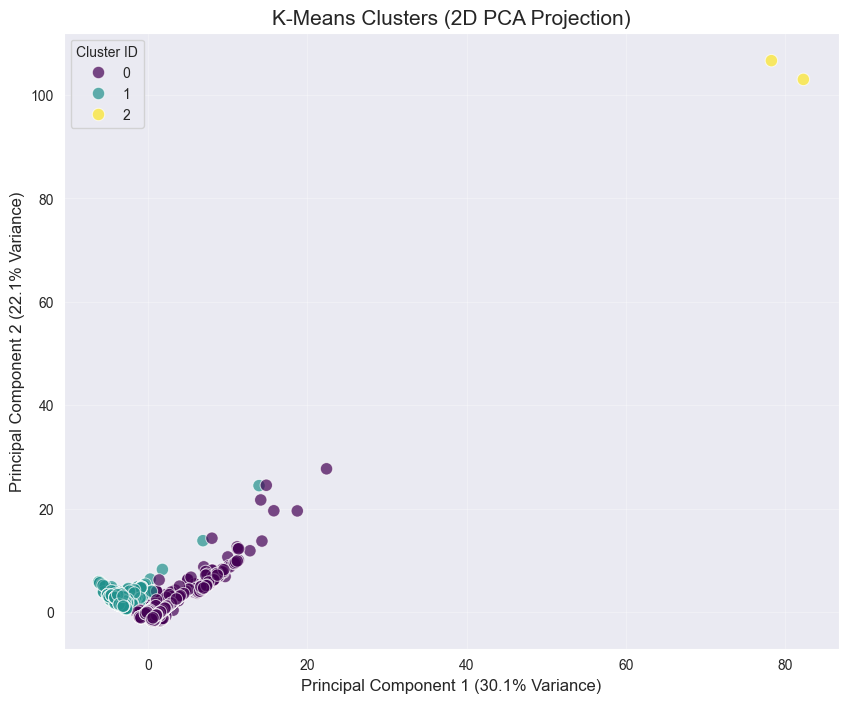

In [11]:
# Ensures plots are displayed directly in the notebook
%matplotlib inline 

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns # Optional: Makes plots look nicer

# ==========================
# 5) PCA for 2D Visualization
# ==========================

# Check if X_scaled exists
if 'X_scaled' not in locals():
    print("Error: X_scaled is missing. Please run the Scaling step first.")
else:
    # 1. Apply PCA
    pca_2d = PCA(n_components=2, random_state=2025)
    X_pca_2d = pca_2d.fit_transform(X_scaled)

    # 2. Create DataFrame for plotting
    df_pca_2d = pd.DataFrame(data=X_pca_2d, columns=['PC1', 'PC2'])
    df_pca_2d['cluster'] = df['cluster'].values

    # 3. Plot
    plt.figure(figsize=(10, 8))
    
    # Using Seaborn for easier handling of clusters/legends
    sns.scatterplot(
        x='PC1', 
        y='PC2', 
        hue='cluster', 
        palette='viridis', 
        data=df_pca_2d, 
        s=80, 
        alpha=0.7,
        edgecolor='w'
    )

    # Labels
    plt.title('K-Means Clusters (2D PCA Projection)', fontsize=15)
    plt.xlabel(f'Principal Component 1 ({pca_2d.explained_variance_ratio_[0]:.1%} Variance)', fontsize=12)
    plt.ylabel(f'Principal Component 2 ({pca_2d.explained_variance_ratio_[1]:.1%} Variance)', fontsize=12)
    plt.legend(title='Cluster ID', loc='best')
    plt.grid(True, alpha=0.3)
    
    # Explicitly show the plot
    plt.show()

## PCA 3D (linear)

To further inspect the geometry of the K-Means clusters, we extend the PCA projection
to **three components**. While the 2D PCA view shows the broad structure, the 3D
projection offers a clearer picture of how the clusters overlap or separate in a higher
portion of the variance.

This visualization allows us to evaluate:

- whether K-Means forms compact and distinguishable groups,
- whether clusters overlap significantly (expected due to K-Means limitations),
- and how much additional structure becomes visible when adding a third component.

The figure below displays the sessions in a 3D PCA space, colored according to the
cluster assigned by K-Means.


In [12]:
import plotly.express as px

# ==========================
# 6) PCA for 3D Visualization
# ==========================

# 1. Apply PCA for 3 components
pca_3d = PCA(n_components=3, random_state=2025)
X_pca_3d = pca_3d.fit_transform(X_scaled)

# 2. Create DataFrame
df_pca_3d = pd.DataFrame(X_pca_3d, columns=['PC1', 'PC2', 'PC3'])
df_pca_3d['cluster'] = df['cluster'].values.astype(str) # Convert to string so Plotly treats it as categorical color

# 3. Create Interactive Plot
fig = px.scatter_3d(
    df_pca_3d, 
    x='PC1', 
    y='PC2', 
    z='PC3',
    color='cluster',
    title='K-Means Clusters (3D PCA)',
    opacity=0.8,
    size_max=1
)

fig.update_layout(
    scene=dict(
        xaxis_title=f'PC1 ({pca_3d.explained_variance_ratio_[0]:.1%})',
        yaxis_title=f'PC2 ({pca_3d.explained_variance_ratio_[1]:.1%})',
        zaxis_title=f'PC3 ({pca_3d.explained_variance_ratio_[2]:.1%})'
    ),
    width=900,
    height=600
)

fig.show()

## t-SNE 3D (non-linear)

Because PCA is a linear projection, it may fail to reveal complex structures present in
the attacker behavior space. To complement the analysis, we use **t-SNE**, a non-linear
dimensionality reduction method that preserves local similarity patterns much better
than PCA.

By embedding the dataset into a 3-dimensional t-SNE space, we can observe:

- whether the K-Means clusters form coherent groups when viewed through a non-linear
  manifold,
- whether sessions assigned to the same cluster truly share local similarity,
- and if the data contains meaningful substructures that K-Means cannot capture.

The 3D scatter plot below visualizes the t-SNE embedding, with each point colored
according to its K-Means cluster assignment.


In [13]:
warnings.filterwarnings("ignore")
# 1) t-SNE with 3 components

# t-SNE is computationally expensive; random_state ensures reproducibility
tsne = TSNE(n_components=3, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

# ==========================
# 1.1) SCALE t-SNE OUTPUT FOR VISUALIZATION
# ==========================
scaler_vis = MinMaxScaler()
X_tsne_vis = scaler_vis.fit_transform(X_tsne)

# ==========================
# 2) Prepare clusters
# ==========================
clusters = df['cluster'].values
unique_clusters = np.unique(clusters)

# ==========================
# 3) Create interactive figure
# ==========================
fig = go.Figure()
colors = ['red', 'blue', 'green']

for i, cluster in enumerate(unique_clusters):
    cluster_mask = clusters == cluster
    label = f"Cluster {cluster}"

    fig.add_trace(go.Scatter3d(
        x=X_tsne_vis[cluster_mask, 0],
        y=X_tsne_vis[cluster_mask, 1],
        z=X_tsne_vis[cluster_mask, 2],
        mode='markers',
        marker=dict(
            size=2,
            color=colors[i % len(colors)],
            opacity=0.7
        ),
        name=label
    ))

# ==========================
# 4) Layout
# ==========================
fig.update_layout(
    title="K-Means Clusters (t-SNE 3D)",
    scene=dict(
        xaxis_title='t-SNE 1',
        yaxis_title='t-SNE 2',
        zaxis_title='t-SNE 3'
    ),
    width=800,
    height=600
)

# ==========================
# 5) Show figure
# ==========================
fig.show()

In [14]:
df[df['cluster'] == 1].head(5)

,num_events,num_commands,session_duration,max_inter_command_time,mean_inter_command_time,std_inter_command_time,command_error_rate,file_transfer_ratio,login_error_rate,reconnaissance_ratio,exploit_ratio,unique_commands_ratio,command_diversity,cluster
session_id,,,,,,,,,,,,,,
010ad96c3f21,16.0,7.0,68.448152,19.502649,3.257964,7.958238,0.428571,0.0,0.0,0.000000,0.062500,0.285714,6.0,1
01310728d909,21.0,9.0,17.792190,1.408968,1.240789,0.217969,0.000000,0.0,0.0,0.095238,0.047619,0.500000,11.0,1
01efe494fcc0,16.0,7.0,68.608636,19.424206,3.242624,7.927324,0.428571,0.0,0.0,0.000000,0.062500,0.285714,6.0,1
02c2ce40e41c,16.0,7.0,68.342209,19.261767,3.215242,7.861160,0.428571,0.0,0.0,0.000000,0.062500,0.285714,6.0,1
035b50f2544d,16.0,7.0,68.438979,19.373217,3.233841,7.906647,0.428571,0.0,0.0,0.000000,0.062500,0.285714,6.0,1


### **Conclusion on the K-Means Clustering Approach**

Upon analyzing the dimensionality reduction visualizations (PCA and t-SNE), we observe a significant limitation in the K-Means results. The projected data appears largely as a **single, dense "giant cluster"**, indicating that the three assigned clusters are heavily overlapped rather than spatially distinct.

Specifically, the algorithm attempted to partition the main data mass into two subgroups of roughly similar size, but these groups lack any clear decision boundary. Additionally, one of the clusters contains only a negligible number of samples (e.g., two data points), which suggests that K-Means is primarily isolating **outliers** rather than discovering a meaningful behavioral category. Meanwhile, the samples assigned to the remaining cluster (Cluster 2) are fully mixed within the dominant behavioral region.

This failure arises from the **geometric assumptions** underlying the K-Means algorithm. K-Means minimizes the Euclidean distance to cluster centroids, implicitly assuming that clusters are:

- **Spherical (isotropic)**
- **Convex** (any point-to-point line segment lies within the cluster)

However, the behavioral patterns of SSH attackers generate **complex, non-convex, and highly irregular manifolds**. Under these conditions, K-Means lacks the ability to separate meaningful behavioral structures and instead forces the data into artificial, centroid-based partitions.

Therefore, K-Means proves **unsuitable for this dataset**, reinforcing the need for **density-based clustering methods** (such as DBSCAN or HDBSCAN) that can detect **arbitrary cluster shapes**, isolate noise, and capture the true intrinsic structure of attacker behavior.
